# Preprocessing Parity Diagnostic — Offline vs Online

Compares features produced by the **offline preprocessor** (used at training
time) against features produced by the **online preprocessor** (used at
inference time) when both consume the same recording. The plots are the
primary deliverable; the JSON report from `scripts/preproc_parity_check.py`
is the machine-readable equivalent.

**Working hypothesis.** The live-inference notebook
[validate_live_inference_epoched.ipynb](validate_live_inference_epoched.ipynb)
shows decoders failing on their own training data (diagonal of the cell-17
table not winning). That should not be possible with a correctly-wired
pipeline. Either the features feeding the trained classifier at inference
time are not what it was trained on, or the channel ordering has drifted.

**Method.** Run both pipelines on the same VHDR; epoch both at the same
event times; compare per channel × time. Then stage-bisect to localize any
divergence. Finally, push features at the trained timepoint through
`LiveInferenceEngine.predict` for every branch and plot the resulting
decoder × marker probability heatmaps. The branch whose heatmap restores
diagonal dominance identifies the bug.

*Diagnostic only — does not modify production code.*

In [1]:
import sys
from pathlib import Path

# Locate REPO_ROOT regardless of where Jupyter was launched.
_search = Path().resolve()
REPO_ROOT = None
while _search != _search.parent:
    if (_search / "src" / "backend").exists() and (_search / "scripts").exists():
        REPO_ROOT = _search
        for extra in ("src", "scripts"):
            target = str(_search / extra)
            if target not in sys.path:
                sys.path.insert(0, target)
        break
    _search = _search.parent

import matplotlib
matplotlib.use("inline")
import matplotlib.pyplot as plt
import numpy as np
import mne
mne.set_log_level("ERROR")

# Pull every helper from the script so plots and metrics share one source of truth.
import preproc_parity_check as parity
from backend.core.settings_manager import SettingsManager
from backend.online_phase.artifact_loader import load_decoder_pipeline_artifact
from backend.online_phase.live_inference import LiveInferenceEngine

print("repo root:", REPO_ROOT)

repo root: /home/itaipap/projects/university/live-reactivation-decoder


---
## Configuration

Mirror the paths the live-inference notebook uses so we're diagnosing the same
artifact / recording / config that produced the broken results.

In [2]:
CONFIG_PATH   = REPO_ROOT / "debug_snapshots" / "experiment_config.yaml"
ARTIFACT_PATH = REPO_ROOT / "debug_snapshots" / "models" / "decoder_pipeline.joblib"
RECORDING_DIR = REPO_ROOT / "data" / "split" / "functional_localizer"
WORK_DIR      = Path("/tmp/parity_check_work_notebook")

CHUNK_SAMPLES = 40   # mirrors StreamWorker / the live-inference notebook
MAX_SECONDS   = 1000  # crop the recording — keeps memory under 4 GB on dev box.
                     #   Set to None to run the full recording.
RUN_ALT_STAGE = False  # The alt-stage twin doubles memory; disable until the
                       # default-stage diagnosis is in hand.

# Bisection variants will use these labels (must match script keys).
BISECTION_LABELS = ["ica_off", "bad_interp_off", "notch_off", "offline_baseline_off"]

---
## Load settings, artifact, and derive expectations

In [3]:
def _find_vhdr(directory):
    matches = list(Path(directory).glob("*.vhdr"))
    if not matches:
        raise FileNotFoundError(f"No .vhdr in {directory}")
    return matches[0]

VHDR_PATH = _find_vhdr(RECORDING_DIR)

settings = SettingsManager(CONFIG_PATH)
artifact = load_decoder_pipeline_artifact(ARTIFACT_PATH)
preprocessing_settings = settings.get_preprocessing_params()

decoding_timepoint = float(artifact.metadata["decoding_timepoint"])
tmin_epoch  = float(preprocessing_settings["epochs"]["tmin"])
tmax_epoch  = float(preprocessing_settings["epochs"]["tmax"])
target_sfreq = float(preprocessing_settings["final_resample"]["target_rate"])

event_mapping = settings.get_event_mapping()           # name -> code
name_by_code  = {v: k for k, v in event_mapping.items()}
marker_names  = parity._marker_names_from_settings(settings)

print(f"VHDR             : {VHDR_PATH.name}")
print(f"resample_filter_stage: {preprocessing_settings.get('resample_filter_stage')}")
print(f"decoding_timepoint   : {decoding_timepoint:.3f}s")
print(f"epoch window         : [{tmin_epoch}, {tmax_epoch}]s @ {target_sfreq:g} Hz")
print(f"marker names         : {marker_names}")
print(f"task names           : {list(artifact.models.keys())}")

/home/itaipap/miniconda3/envs/reactivation-decoder/lib/python3.12/site-packages/sklearn/base.py:442: InconsistentVersionWarning: Trying to unpickle estimator StandardScaler from version 1.8.0 when using version 1.7.2. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(


VHDR             : BindingDecoding001.vhdr
resample_filter_stage: early
decoding_timepoint   : 0.140s
epoch window         : [-0.2, 1.0]s @ 100 Hz
marker names         : ['red', 'green', 'yellow', 'living_room', 'bathroom', 'kitchen']
task names           : ['red decoder', 'green decoder', 'yellow decoder', 'living_room decoder', 'bathroom decoder', 'kitchen decoder']


/home/itaipap/miniconda3/envs/reactivation-decoder/lib/python3.12/site-packages/sklearn/base.py:442: InconsistentVersionWarning: Trying to unpickle estimator LinearDiscriminantAnalysis from version 1.8.0 when using version 1.7.2. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
/home/itaipap/miniconda3/envs/reactivation-decoder/lib/python3.12/site-packages/sklearn/base.py:442: InconsistentVersionWarning: Trying to unpickle estimator Pipeline from version 1.8.0 when using version 1.7.2. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(


---
## Channel-name alignment

Before computing any per-channel metric: do the channel names the offline
pipeline produces (post-hygiene EEG order) match the channel names the
online preprocessor implicitly operates on (derived from `eeg_chunk_indices`
on the pre-hygiene VHDR order, with hygiene renames applied)?

If they don't, **every** downstream per-channel comparison is permuted
garbage. The strip plot below colors each channel position green for match,
red for mismatch.

In [4]:
# Derive the two name lists. ch_names are in the .vhdr header so we don't
# need to preload the multi-GB .eeg payload here.
raw_pre = mne.io.read_raw_brainvision(str(VHDR_PATH), preload=False, verbose="ERROR")
derived_online_names = parity.derive_online_channel_names(raw_pre, artifact)

print(f"raw pre-hygiene channels: {len(raw_pre.ch_names)}")
print(f"derived online channels : {len(derived_online_names)}")
print(f"first 10 derived         : {derived_online_names[:10]}")

raw pre-hygiene channels: 65
derived online channels : 64
first 10 derived         : ['Fp1', 'Fp2', 'F3', 'F4', 'C3', 'C4', 'P3', 'P4', 'O1', 'O2']


---
## Run both pipelines (default stage)

This is the heavy step (full offline pipeline + ICA fit, plus the streaming
online pass). Result cached in `pass_outputs` so subsequent cells don't
recompute.

In [5]:
WORK_DIR.mkdir(parents=True, exist_ok=True)

pass_outputs = parity.run_single_stage_pass(
    vhdr_path=VHDR_PATH,
    settings=settings,
    artifact=artifact,
    work_dir=WORK_DIR,
    chunk_samples=CHUNK_SAMPLES,
    preprocessing_settings=preprocessing_settings,
    max_seconds=MAX_SECONDS,
)

offline_array = pass_outputs["offline_array"]                # (n_trials, n_ch, n_samples)
online_array  = pass_outputs["baseline_online_array"]        # (n_trials, n_ch, n_samples)
event_codes   = pass_outputs["offline_event_codes"]
offline_ch_names = pass_outputs["offline_epochs"].ch_names

print(f"offline epochs: {offline_array.shape}  std={offline_array.std():.2e}")
print(f"online  epochs: {online_array.shape}   std={online_array.std():.2e}")
print(f"events        : {len(event_codes)} trials, codes={sorted(set(event_codes.tolist()))}")

[offline 1/3] filtering (HP + notch + LP/resample if early-stage)...
[offline 2/3] fitting ICA (0 bad channels seeded from artifact)...
[offline 3/3] applying ICA + epoching...
[offline done] 398 epochs


online streaming:   0%|          | 0/25001 [00:00<?, ?batch/s]

offline epochs: (398, 64, 121)  std=8.44e-06
online  epochs: (398, 64, 121)   std=1.26e-05
events        : 398 trials, codes=[11, 12, 13, 16, 17, 18, 31, 32]


Now run the alignment check against the offline epochs' `ch_names`.

all_match=True  matched=64/64


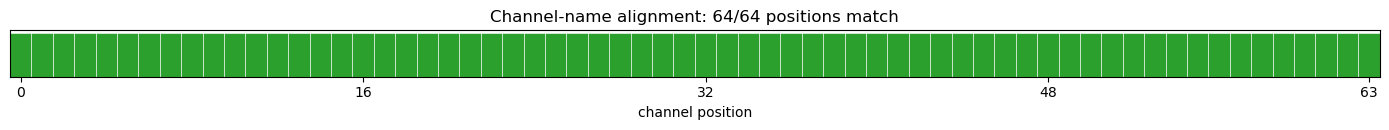

In [6]:
alignment = parity.check_channel_alignment(offline_ch_names, derived_online_names)

print(f"all_match={alignment.all_match}  matched={alignment.n_match}/{alignment.n_positions}")
if not alignment.all_match:
    print("\nFirst 8 mismatches:")
    shown = 0
    for row in alignment.rows:
        if row.match:
            continue
        print(f"  pos {row.position:>3d}: offline={row.offline_name!s:<8s} derived={row.derived_name!s}")
        shown += 1
        if shown >= 8:
            break

# Plot: strip of cells, one per channel position, green for match / red for mismatch.
fig, ax = plt.subplots(figsize=(14, 1.4))
colors = ["#2ca02c" if row.match else "#d62728" for row in alignment.rows]
ax.bar(range(alignment.n_positions), [1] * alignment.n_positions, color=colors, width=1.0, edgecolor="white", linewidth=0.4)
ax.set_xticks([0, alignment.n_positions // 4, alignment.n_positions // 2, 3 * alignment.n_positions // 4, alignment.n_positions - 1])
ax.set_yticks([])
ax.set_xlim(-0.5, alignment.n_positions - 0.5)
ax.set_title(f"Channel-name alignment: {alignment.n_match}/{alignment.n_positions} positions match")
ax.set_xlabel("channel position")
plt.tight_layout(); plt.show()

---
## Per-trial divergence metrics — histograms

Compute `trial_metrics` (max|Δ|, mean channel corr, aligned corr with up to
±50 ms lag search, best lag in ms) for every trial of the baseline branch.
The histograms reveal whether divergence is uniformly bad across trials or
trial-dependent.

Thresholds (red dashed lines): aligned_corr ≥ 0.95, |lag| ≤ 50 ms,
max|Δ|/σ ≤ 0.25.

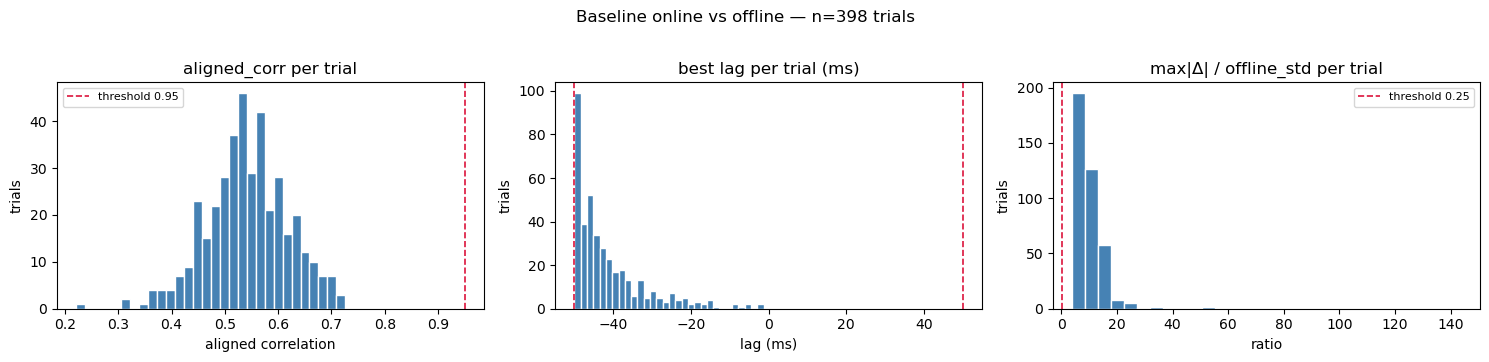

medians: aligned_corr=+0.540  lag=-44.7ms  max|Δ|/σ=8.850


In [7]:
# Per-trial metrics for the default-stage baseline online vs offline.
# compare_branches trims to (min n_trials, min n_samples), so this is
# robust if the active stage flips to 'late' too.
baseline_summary = parity.compare_branches(offline_array, online_array, target_sfreq, label="baseline")
trials = baseline_summary.trials
n_trials = len(trials)

aligned_corrs = np.array([t.aligned_corr for t in trials])
lags_ms       = np.array([t.best_lag_ms for t in trials])
max_abs_diffs = np.array([t.max_abs_diff for t in trials])
offline_std   = float(np.std(offline_array))
diff_ratios   = max_abs_diffs / offline_std

# Three-panel histogram.
fig, axes = plt.subplots(1, 3, figsize=(15, 3.5))

axes[0].hist(aligned_corrs, bins=30, color="steelblue", edgecolor="white")
axes[0].axvline(0.95, color="crimson", ls="--", lw=1.2, label="threshold 0.95")
axes[0].set(title="aligned_corr per trial", xlabel="aligned correlation", ylabel="trials")
axes[0].legend(fontsize=8)

axes[1].hist(lags_ms, bins=30, color="steelblue", edgecolor="white")
for thr in (-50, 50):
    axes[1].axvline(thr, color="crimson", ls="--", lw=1.2)
axes[1].set(title="best lag per trial (ms)", xlabel="lag (ms)", ylabel="trials")

axes[2].hist(diff_ratios, bins=30, color="steelblue", edgecolor="white")
axes[2].axvline(0.25, color="crimson", ls="--", lw=1.2, label="threshold 0.25")
axes[2].set(title="max|Δ| / offline_std per trial", xlabel="ratio", ylabel="trials")
axes[2].legend(fontsize=8)

plt.suptitle(f"Baseline online vs offline — n={n_trials} trials", y=1.02)
plt.tight_layout(); plt.show()

print(f"medians: aligned_corr={np.median(aligned_corrs):+.3f}  "
      f"lag={np.median(lags_ms):+.1f}ms  "
      f"max|Δ|/σ={np.median(diff_ratios):.3f}")

---
## Trace overlays — offline vs online on representative trials

For one trial per marker type, pick 3 occipital and 2 frontal channels and
overlay offline (navy) on online (orange). Vertical lines mark `t = 0` (the
stimulus) and `t = decoding_timepoint` (where the model is queried).

Visually: identical traces → parity. Constant offset → DC mismatch (e.g.
baseline policy). Time-shifted but same shape → filter-mode mismatch.
Completely different shape → ICA / channel-order issue.

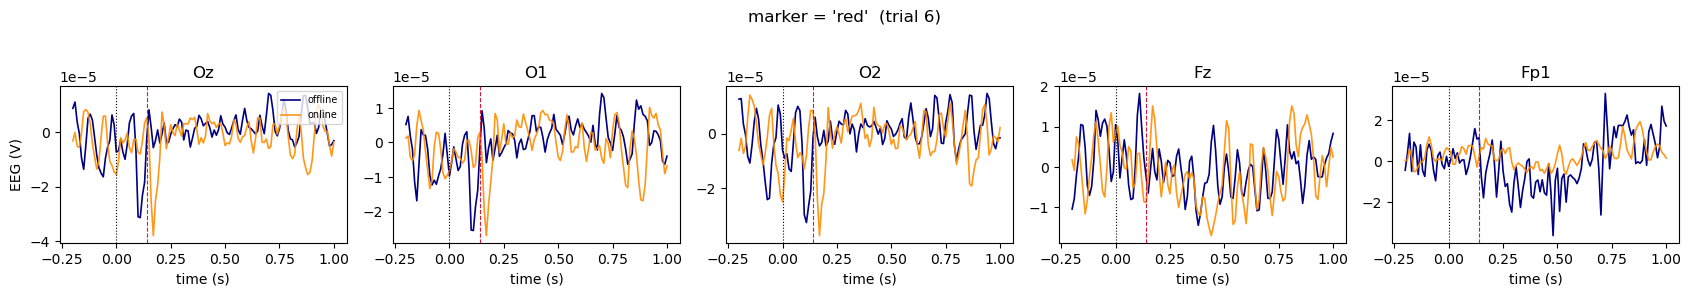

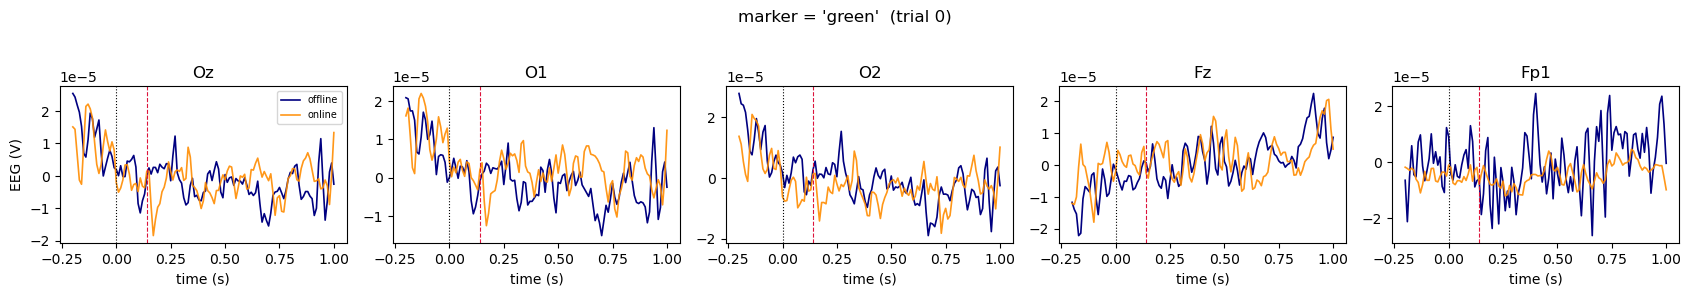

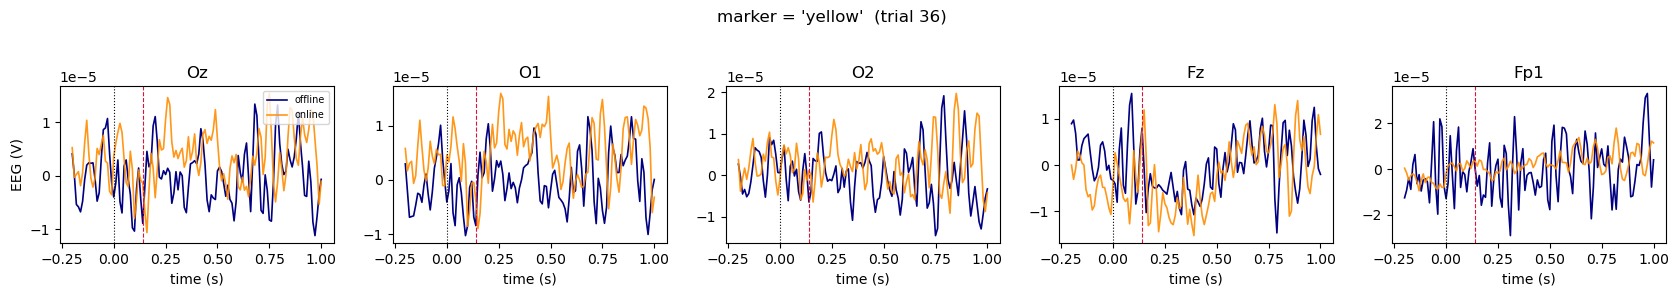

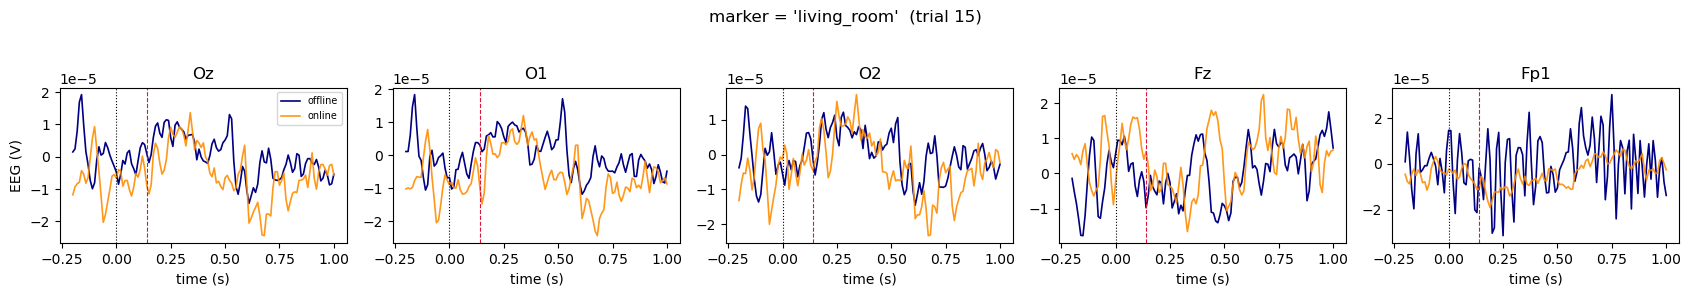

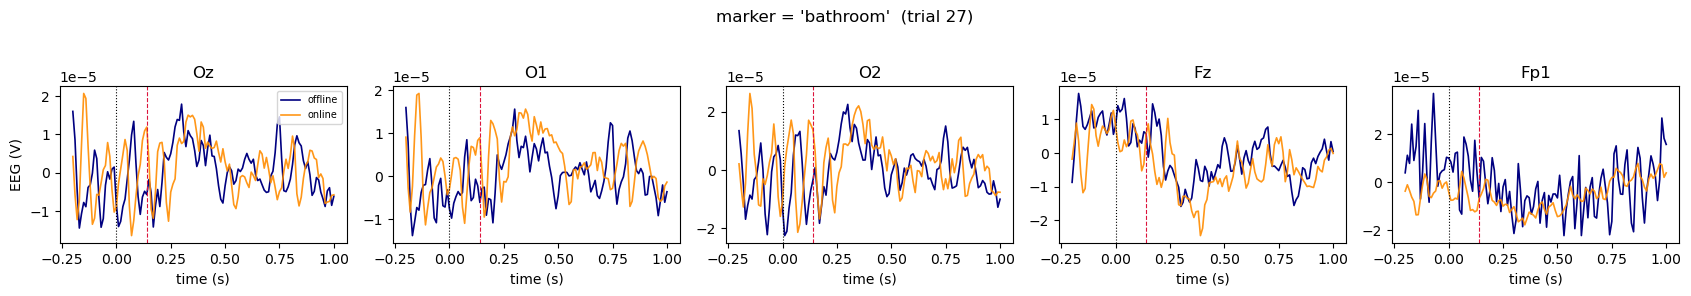

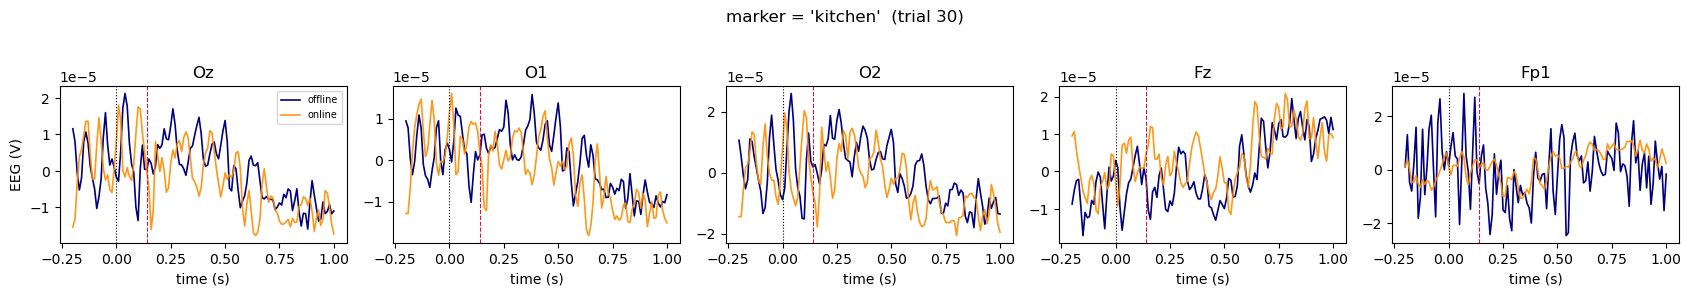

In [8]:
# Pick a representative trial for each marker (first match).
trial_for_marker = {}
for marker_name, code in event_mapping.items():
    if marker_name not in marker_names:
        continue
    where = np.where(event_codes == code)[0]
    if where.size:
        trial_for_marker[marker_name] = int(where[0])

# Pick channels: bias toward occipital (where visual-evoked is strong) and a couple frontal.
def _pick_channels(ch_names, occipital=("Oz", "O1", "O2", "POz"), frontal=("Fz", "AFz", "Fp1", "Fp2")):
    occ = [n for n in occipital if n in ch_names][:3]
    fro = [n for n in frontal   if n in ch_names][:2]
    if not occ:
        occ = [ch_names[0]]
    if not fro:
        fro = [ch_names[1] if len(ch_names) > 1 else ch_names[0]]
    return occ + fro

channels_to_plot = _pick_channels(offline_ch_names)
ch_idx = [offline_ch_names.index(name) for name in channels_to_plot]
t_grid = tmin_epoch + np.arange(offline_array.shape[2]) / target_sfreq

for marker_name, trial_index in trial_for_marker.items():
    fig, axes = plt.subplots(1, len(channels_to_plot), figsize=(3.4 * len(channels_to_plot), 2.8), sharey=False)
    for col, (name, idx) in enumerate(zip(channels_to_plot, ch_idx)):
        ax = axes[col] if len(channels_to_plot) > 1 else axes
        ax.plot(t_grid, offline_array[trial_index, idx], color="navy", lw=1.2, label="offline")
        ax.plot(t_grid, online_array[trial_index, idx],  color="darkorange", lw=1.2, alpha=0.9, label="online")
        ax.axvline(0.0, color="k", ls=":", lw=0.8)
        ax.axvline(decoding_timepoint, color="crimson", ls="--", lw=0.8)
        ax.set(title=name, xlabel="time (s)")
        if col == 0:
            ax.set_ylabel("EEG (V)")
            ax.legend(fontsize=7, loc="upper right")
    plt.suptitle(f"marker = {marker_name!r}  (trial {trial_index})", y=1.04)
    plt.tight_layout(); plt.show()

---
## Difference heatmap — `offline − online` per trial

One heatmap per marker. Reveals where divergence concentrates:

- **Uniform horizontal bands** → DC offset on those channels (baseline /
  reference / scaling).
- **Vertical streaks at t=0 or t=trained_tp** → transient (filter response,
  ICA at apply time).
- **Bright everywhere** → catastrophic mismatch (channel permutation or
  unit scaling).

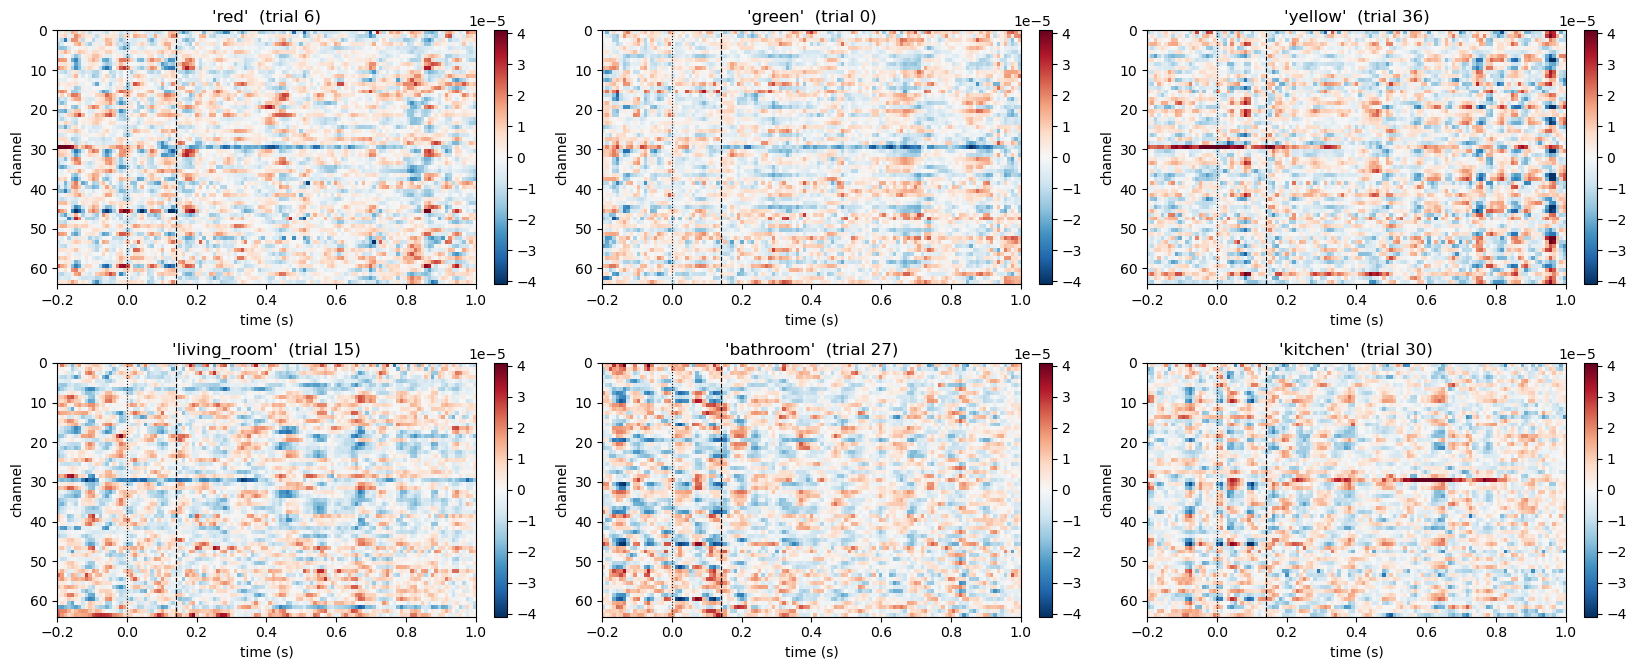

In [9]:
ncols = 3
nrows = (len(trial_for_marker) + ncols - 1) // ncols
fig, axes = plt.subplots(nrows, ncols, figsize=(5.5 * ncols, 3.4 * nrows), squeeze=False)
vmax = float(np.percentile(np.abs(offline_array - online_array), 99))

for plot_idx, (marker_name, trial_index) in enumerate(trial_for_marker.items()):
    ax = axes[plot_idx // ncols][plot_idx % ncols]
    diff = offline_array[trial_index] - online_array[trial_index]  # (n_ch, n_samples)
    im = ax.imshow(
        diff,
        aspect="auto",
        cmap="RdBu_r",
        vmin=-vmax,
        vmax=+vmax,
        extent=[t_grid[0], t_grid[-1], diff.shape[0], 0],
    )
    ax.axvline(0.0, color="k", ls=":", lw=0.8)
    ax.axvline(decoding_timepoint, color="black", ls="--", lw=0.8)
    ax.set(title=f"{marker_name!r}  (trial {trial_index})", xlabel="time (s)", ylabel="channel")
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

for empty_idx in range(len(trial_for_marker), nrows * ncols):
    axes[empty_idx // ncols][empty_idx % ncols].axis("off")
plt.tight_layout(); plt.show()

---
## Stage bisection

For each stage variant, the online pipeline is re-run with one stage
disabled (or, in the `offline_baseline_off` case, with the offline epochs
re-cast as non-baseline-corrected). The metric histogram triplet is stacked
side-by-side so the variant that flips parity from red to green pops out.

If any row's three histograms suddenly cluster near (1.0, 0, 0) — that's
the broken stage.

[bisection] running 3 online-side variants + 1 offline-side variant...


bisection:   0%|          | 0/3 [00:00<?, ?it/s]

online streaming:   0%|          | 0/25001 [00:00<?, ?batch/s]

online streaming:   0%|          | 0/25001 [00:00<?, ?batch/s]

online streaming:   0%|          | 0/25001 [00:00<?, ?batch/s]

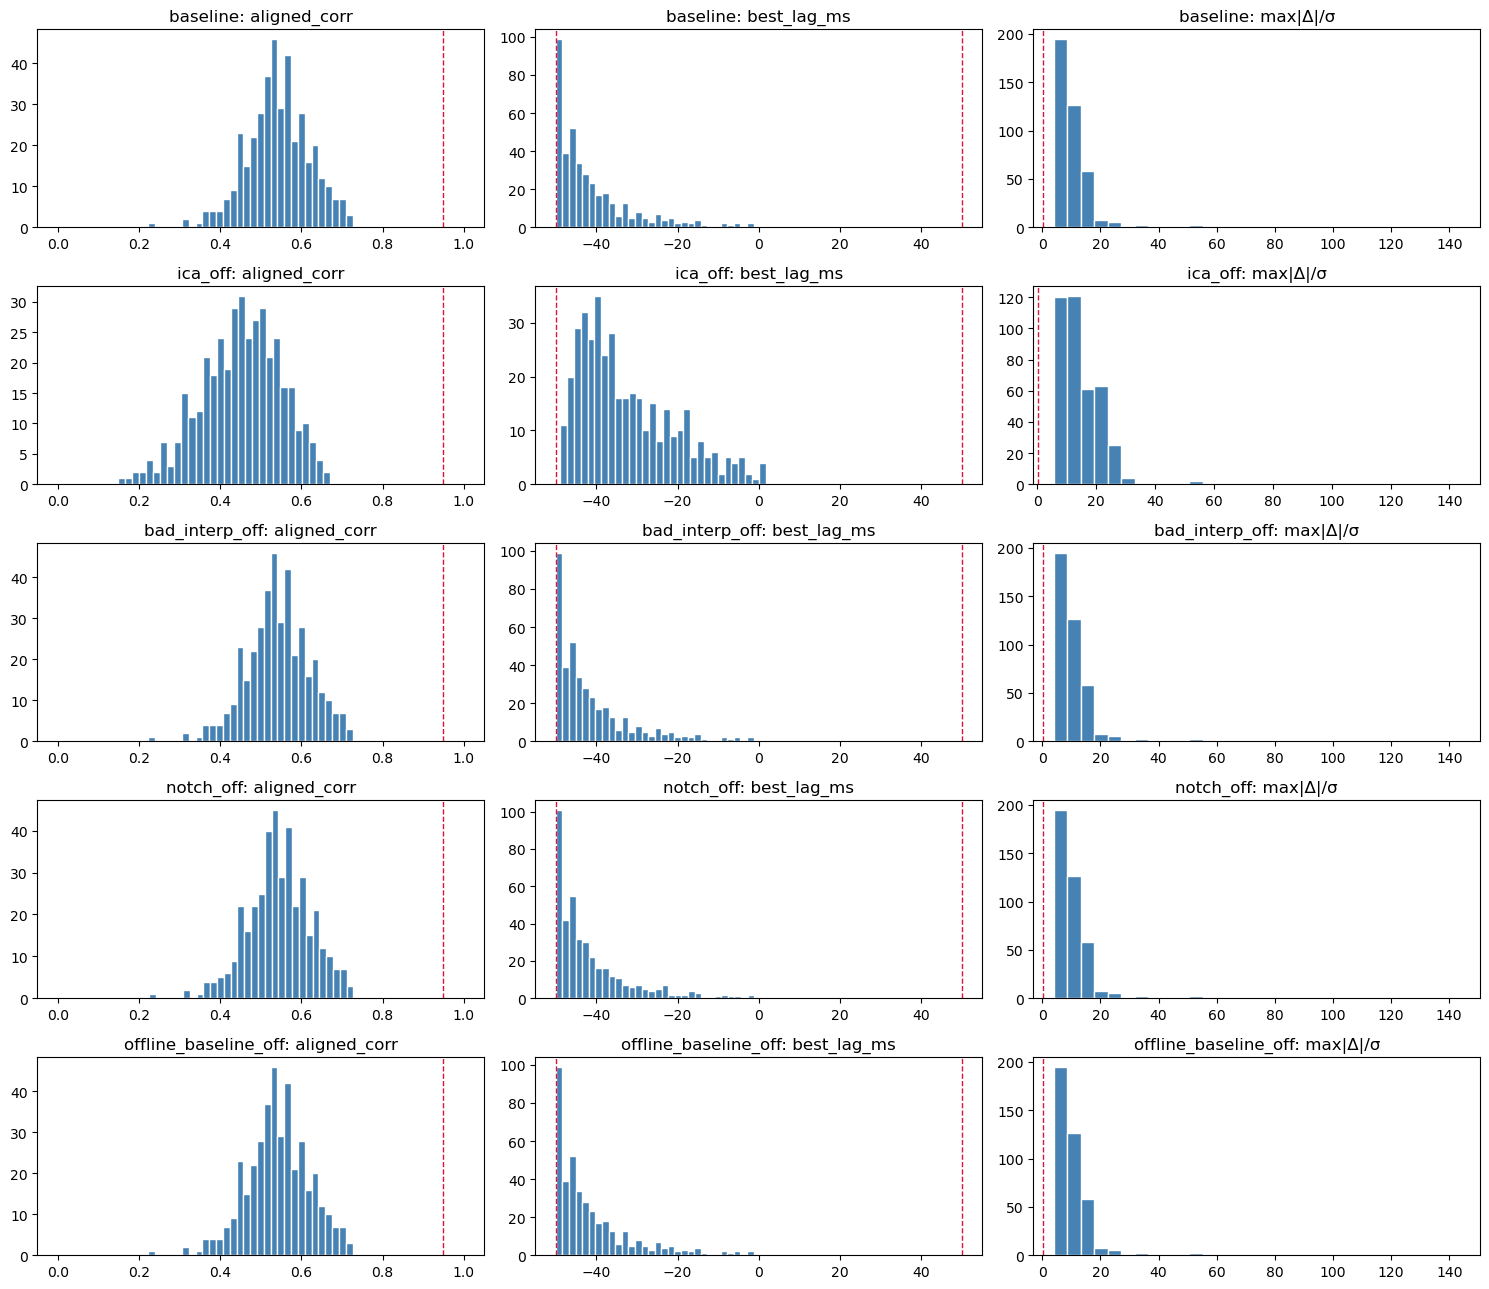

variant                 aligned_corr      lag_ms      max|Δ|/σ
--------------------------------------------------------------
baseline                      +0.540       -44.7         8.850
ica_off                       +0.455       -35.9        13.200
bad_interp_off                +0.540       -44.7         8.850
notch_off                     +0.543       -45.0         8.868
offline_baseline_off          +0.540       -44.7         8.850


In [10]:
bisection_summaries = parity.run_bisection_sweep(
    pass_outputs=pass_outputs,
    vhdr_path=VHDR_PATH,
    artifact=artifact,
    chunk_samples=CHUNK_SAMPLES,
    max_seconds=MAX_SECONDS,
)

# Pull per-trial metric arrays out of each summary for plotting.
def _metric_arrays(summary):
    return (
        np.array([t.aligned_corr for t in summary.trials]),
        np.array([t.best_lag_ms for t in summary.trials]),
        np.array([t.max_abs_diff for t in summary.trials]) / offline_std,
    )

# Stacked histograms: row per variant (including baseline as the top row), 3 cols.
all_branches = [("baseline", trials)] + [(s.label, s.trials) for s in bisection_summaries]
nrows = len(all_branches)
fig, axes = plt.subplots(nrows, 3, figsize=(15, 2.6 * nrows), squeeze=False)
for row_idx, (label, branch_trials) in enumerate(all_branches):
    if not branch_trials:
        for col in range(3):
            axes[row_idx][col].axis("off")
            axes[row_idx][col].set_title(f"{label} (no trials)")
        continue
    aligned = np.array([t.aligned_corr for t in branch_trials])
    lags    = np.array([t.best_lag_ms  for t in branch_trials])
    diffs   = np.array([t.max_abs_diff for t in branch_trials]) / offline_std

    axes[row_idx][0].hist(aligned, bins=30, color="steelblue", edgecolor="white")
    axes[row_idx][0].axvline(0.95, color="crimson", ls="--", lw=1.0)
    axes[row_idx][0].set(title=f"{label}: aligned_corr", xlim=(-0.05, 1.05))

    axes[row_idx][1].hist(lags, bins=30, color="steelblue", edgecolor="white")
    for thr in (-50, 50):
        axes[row_idx][1].axvline(thr, color="crimson", ls="--", lw=1.0)
    axes[row_idx][1].set(title=f"{label}: best_lag_ms")

    axes[row_idx][2].hist(diffs, bins=30, color="steelblue", edgecolor="white")
    axes[row_idx][2].axvline(0.25, color="crimson", ls="--", lw=1.0)
    axes[row_idx][2].set(title=f"{label}: max|Δ|/σ")

plt.tight_layout(); plt.show()

# Print median table.
print(f"{'variant':<22s}{'aligned_corr':>14s}{'lag_ms':>12s}{'max|Δ|/σ':>14s}")
print("-" * 62)
print(f"{'baseline':<22s}{np.median(aligned_corrs):>+14.3f}{np.median(lags_ms):>+12.1f}{np.median(diff_ratios):>14.3f}")
for s in bisection_summaries:
    if s.n_trials == 0:
        print(f"{s.label:<22s}{'no trials':>14s}")
        continue
    diff_ratio_median = s.median_max_abs_diff / offline_std if offline_std > 0 else float('nan')
    print(f"{s.label:<22s}{s.median_aligned_corr:>+14.3f}{s.median_best_lag_ms:>+12.1f}{diff_ratio_median:>14.3f}")

---
## Alt-stage comparison

Re-run both branches with `resample_filter_stage` flipped to the other
value. If parity is clean under one stage and broken under the other, the
stage choice itself is the difference — likely a path that wasn't exercised
during training.

In [11]:
if not RUN_ALT_STAGE:
    print("RUN_ALT_STAGE is False — skipping alt-stage twin to save memory.")
else:
    current_stage = preprocessing_settings.get("resample_filter_stage", "early")
    flipped_stage = "late" if current_stage == "early" else "early"
    alt_settings = parity._override_stage(preprocessing_settings, flipped_stage)

    alt_pass = parity.run_single_stage_pass(
        vhdr_path=VHDR_PATH,
        settings=settings,
        artifact=artifact,
        work_dir=WORK_DIR / f"alt_{flipped_stage}",
        chunk_samples=CHUNK_SAMPLES,
        preprocessing_settings=alt_settings,
        max_seconds=MAX_SECONDS,
    )

    alt_offline = alt_pass["offline_array"]
    alt_online  = alt_pass["baseline_online_array"]
    alt_sfreq   = float(alt_settings["final_resample"]["target_rate"])

    # compare_branches trims to the common (n_trials, n_samples). Important
    # for late-stage: MNE drops 1 sample on Epochs.resample, so offline can
    # be 120 vs online 121 — handled silently here.
    alt_summary = parity.compare_branches(alt_offline, alt_online, alt_sfreq, label=f"baseline_{flipped_stage}")
    alt_trials  = alt_summary.trials

    alt_aligned = np.array([t.aligned_corr for t in alt_trials])
    alt_lags    = np.array([t.best_lag_ms  for t in alt_trials])
    alt_diffs   = np.array([t.max_abs_diff for t in alt_trials]) / float(np.std(alt_offline))

    fig, axes = plt.subplots(2, 3, figsize=(15, 6))
    axes[0][0].hist(aligned_corrs, bins=30, color="steelblue", edgecolor="white")
    axes[0][0].axvline(0.95, color="crimson", ls="--", lw=1.0)
    axes[0][0].set(title=f"{current_stage}: aligned_corr", xlim=(-0.05, 1.05))
    axes[0][1].hist(lags_ms, bins=30, color="steelblue", edgecolor="white")
    for thr in (-50, 50): axes[0][1].axvline(thr, color="crimson", ls="--", lw=1.0)
    axes[0][1].set(title=f"{current_stage}: best_lag_ms")
    axes[0][2].hist(diff_ratios, bins=30, color="steelblue", edgecolor="white")
    axes[0][2].axvline(0.25, color="crimson", ls="--", lw=1.0)
    axes[0][2].set(title=f"{current_stage}: max|Δ|/σ")
    axes[1][0].hist(alt_aligned, bins=30, color="darkorange", edgecolor="white")
    axes[1][0].axvline(0.95, color="crimson", ls="--", lw=1.0)
    axes[1][0].set(title=f"{flipped_stage}: aligned_corr", xlim=(-0.05, 1.05))
    axes[1][1].hist(alt_lags, bins=30, color="darkorange", edgecolor="white")
    for thr in (-50, 50): axes[1][1].axvline(thr, color="crimson", ls="--", lw=1.0)
    axes[1][1].set(title=f"{flipped_stage}: best_lag_ms")
    axes[1][2].hist(alt_diffs, bins=30, color="darkorange", edgecolor="white")
    axes[1][2].axvline(0.25, color="crimson", ls="--", lw=1.0)
    axes[1][2].set(title=f"{flipped_stage}: max|Δ|/σ")
    plt.tight_layout(); plt.show()

    print(f"medians @ stage={current_stage:<5s}: aligned_corr={np.median(aligned_corrs):+.3f}  "
          f"lag={np.median(lags_ms):+.1f}ms  diff={np.median(diff_ratios):.3f}")
    print(f"medians @ stage={flipped_stage:<5s}: aligned_corr={np.median(alt_aligned):+.3f}  "
          f"lag={np.median(alt_lags):+.1f}ms  diff={np.median(alt_diffs):.3f}")

RUN_ALT_STAGE is False — skipping alt-stage twin to save memory.


---
## Probability-level diagnosis — decoder × marker heatmaps

The end-question is "do the decoder outputs match?", not "do the features
match?". For every branch, push features at `decoding_timepoint` through
`LiveInferenceEngine.predict` and aggregate median P(positive) per
decoder × marker.

What to look for:

- **Offline branch**: diagonal **must** dominate on training data
  (leakage). If it doesn't, the offline path itself is broken.
- **Online baseline branch**: this is what the live-inference notebook
  saw collapse. Reproducing the failure here confirms the harness.
- **Any bisected variant whose diagonal recovers**: identifies the
  broken stage.

probability variants:   0%|          | 0/3 [00:00<?, ?it/s]

online streaming:   0%|          | 0/25001 [00:00<?, ?batch/s]

online streaming:   0%|          | 0/25001 [00:00<?, ?batch/s]

online streaming:   0%|          | 0/25001 [00:00<?, ?batch/s]

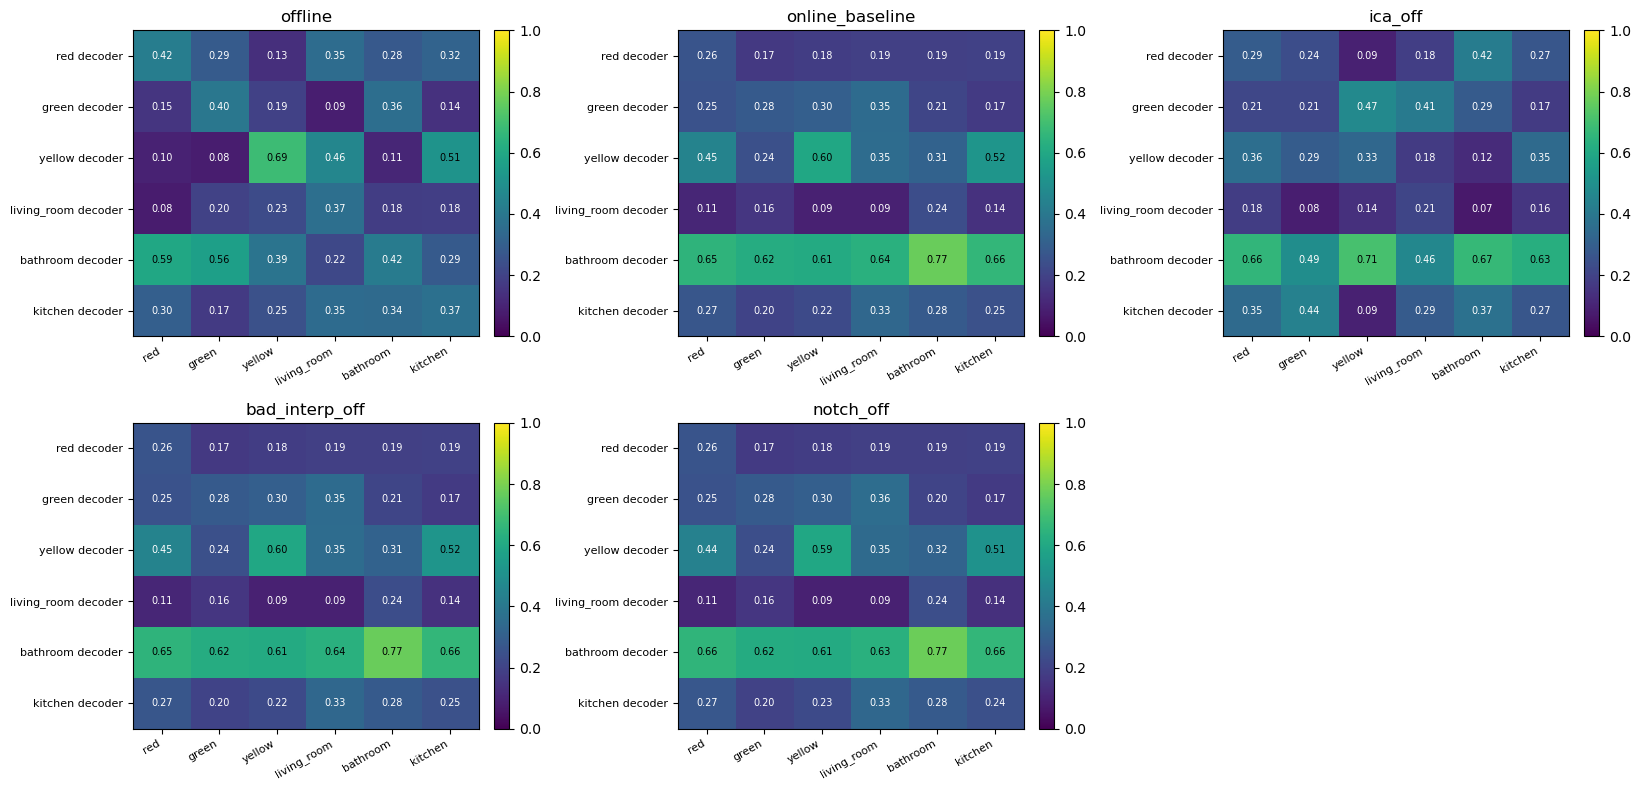

In [12]:
# Probability tables for offline + online baseline.
default_tables = parity.build_probability_tables(
    pass_outputs=pass_outputs,
    artifact=artifact,
    settings=settings,
)

# Also re-stream the bisected variants and compute probability tables for each.
from tqdm.auto import tqdm  # progress for the 3 extra online streaming passes
event_times_s = pass_outputs["offline_event_times_s"]
bisection_arrays = {}
n_ch = int(artifact.online_state["pre_whitener"].shape[0])
bisection_patches = {
    "ica_off":        {"_ica_exclude": []},
    "bad_interp_off": {"_bad_indices": [], "_good_indices": list(range(n_ch))},
    "notch_off":      {"_notch_sos": None},
}
for label, patches in tqdm(bisection_patches.items(), total=len(bisection_patches), desc="probability variants"):
    try:
        online_variant = parity._epoch_online_with_patches(
            vhdr_path=VHDR_PATH,
            artifact=artifact,
            preprocessing_settings=preprocessing_settings,
            chunk_samples=CHUNK_SAMPLES,
            patches=patches,
            event_times_s=event_times_s,
            max_seconds=MAX_SECONDS,
        )
        bisection_arrays[label] = online_variant
    except Exception as exc:
        print(f"  {label}: failed ({exc})")
bisection_tables = parity.build_probability_tables(
    pass_outputs=pass_outputs,
    artifact=artifact,
    settings=settings,
    extra_online_arrays=bisection_arrays,
)
# build_probability_tables always emits offline + online_baseline first; drop those duplicates.
extra_tables = [t for t in bisection_tables if t.branch_label not in {"offline", "online_baseline"}]
all_tables = default_tables + extra_tables

# Plot one heatmap per branch.
ncols = 3
nrows = (len(all_tables) + ncols - 1) // ncols
fig, axes = plt.subplots(nrows, ncols, figsize=(5.5 * ncols, 4.0 * nrows), squeeze=False)
for plot_idx, table in enumerate(all_tables):
    ax = axes[plot_idx // ncols][plot_idx % ncols]
    matrix = np.array([[table.cells[task][marker] for marker in table.marker_names] for task in table.task_names])
    im = ax.imshow(matrix, vmin=0, vmax=1, cmap="viridis", aspect="auto")
    ax.set_xticks(range(len(table.marker_names)))
    ax.set_xticklabels(table.marker_names, rotation=30, ha="right", fontsize=8)
    ax.set_yticks(range(len(table.task_names)))
    ax.set_yticklabels(table.task_names, fontsize=8)
    ax.set_title(f"{table.branch_label}")
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    # Annotate cells.
    for i in range(matrix.shape[0]):
        for j in range(matrix.shape[1]):
            value = matrix[i, j]
            text_color = "white" if value < 0.5 else "black"
            ax.text(j, i, f"{value:.2f}" if np.isfinite(value) else "n/a",
                    ha="center", va="center", color=text_color, fontsize=7)

for empty_idx in range(len(all_tables), nrows * ncols):
    axes[empty_idx // ncols][empty_idx % ncols].axis("off")
plt.tight_layout(); plt.show()

---
## Per-decoder P(t) — offline vs online branches

Sweep `LiveInferenceEngine.predict` across every timepoint in the epoch
window to recover a P(t) trace per task, then average over each decoder's
own positive marker trials. Overlays the offline path (navy) on the online
baseline path (orange) per decoder — direct analog of the existing live-
inference notebook's cell 13, but comparing the two branches at the
feature-equivalent level.

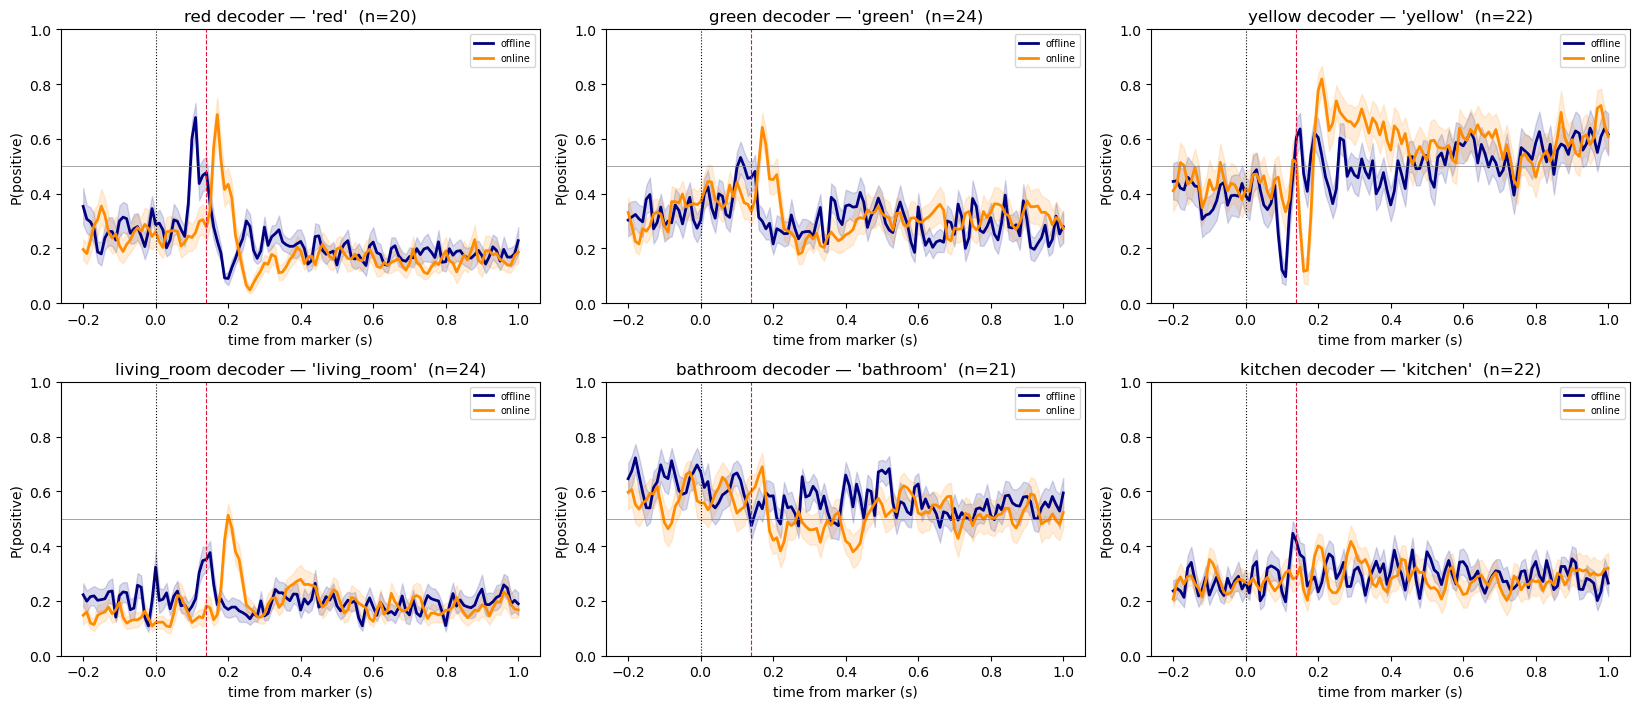

In [13]:
def sweep_predict_over_time(epochs_array, engine):
    # Run predict across every timepoint; return dict[task -> (n_trials, n_samples)].
    n_trials, n_ch, n_samples = epochs_array.shape
    per_task: dict[str, np.ndarray] = {task: np.empty((n_trials, n_samples)) for task in engine.models}
    for t_idx in range(n_samples):
        preds = engine.predict(epochs_array[:, :, t_idx])
        for task, prob in preds.items():
            per_task[task][:, t_idx] = prob
    return per_task

engine = LiveInferenceEngine(artifact.models, artifact.metadata)
offline_pt = sweep_predict_over_time(offline_array, engine)
online_pt  = sweep_predict_over_time(online_array,  engine)

task_names = list(offline_pt.keys())
# Map each task to its own positive marker.
task_pos_marker = {t["name"]: t["pos_labels"][0] for t in settings.get_decoder_settings()["tasks"]}

ncols = 3
nrows = (len(task_names) + ncols - 1) // ncols
fig, axes = plt.subplots(nrows, ncols, figsize=(5.5 * ncols, 3.6 * nrows), squeeze=False)

for plot_idx, task in enumerate(task_names):
    ax = axes[plot_idx // ncols][plot_idx % ncols]
    marker = task_pos_marker.get(task)
    if marker is None:
        ax.axis("off"); continue
    code = event_mapping.get(marker)
    mask = event_codes == code
    if not mask.any():
        ax.set_title(f"{task} — '{marker}' (no trials)"); continue
    off_mean = offline_pt[task][mask].mean(axis=0)
    on_mean  = online_pt[task][mask].mean(axis=0)
    off_sem  = offline_pt[task][mask].std(axis=0) / np.sqrt(mask.sum())
    on_sem   = online_pt[task][mask].std(axis=0)  / np.sqrt(mask.sum())
    ax.plot(t_grid, off_mean, color="navy", lw=2.0, label="offline")
    ax.fill_between(t_grid, off_mean - off_sem, off_mean + off_sem, color="navy", alpha=0.15)
    ax.plot(t_grid, on_mean,  color="darkorange", lw=2.0, label="online")
    ax.fill_between(t_grid, on_mean  - on_sem,  on_mean  + on_sem,  color="darkorange", alpha=0.15)
    ax.axvline(0.0, color="k", ls=":", lw=0.8)
    ax.axvline(decoding_timepoint, color="crimson", ls="--", lw=0.8)
    ax.axhline(0.5, color="gray", lw=0.5)
    ax.set(title=f"{task} — '{marker}'  (n={int(mask.sum())})",
           ylim=(0, 1), xlabel="time from marker (s)", ylabel="P(positive)")
    ax.legend(fontsize=7, loc="upper right")

for empty_idx in range(len(task_names), nrows * ncols):
    axes[empty_idx // ncols][empty_idx % ncols].axis("off")
plt.tight_layout(); plt.show()

---
## Diagnosis summary

Use this cell to write down what the plots above show. Reference the decision
tree in the plan
([~/.claude/plans/jaunty-herding-pebble.md](../../../.claude/plans/jaunty-herding-pebble.md)):

- **Channel-alignment red bars** → permutation bug.
- **`offline_baseline_off` row flips parity from red to green** → baseline policy.
- **`ica_off` row flips parity from red to green** → ICA fit/apply or pre_whitener.
- **`notch_off` / `bad_interp_off` flips** → that stage.
- **`|lag| > 50 ms` while aligned_corr ≥ 0.95** → filter mode (filtfilt vs sosfilt).
- **Probability table: offline diagonal dominant AND online_baseline diagonal
  collapses** → confirms the harness reproduces the broken live-inference state.
- **All metrics green but online probability heatmap still collapses** →
  the bug is downstream of the preprocessor (artifact load, sklearn version,
  feature indexing into the engine).

Whichever bisected variant's probability heatmap restores diagonal dominance
identifies the broken stage.